Imports

In [2]:
from PIL import Image, ImageDraw, ImageFont, ImageFilter
import random, string, os
import matplotlib.pyplot as plt

Locate fonts

In [6]:
FONT_DIR = "C:/Windows/Fonts"
font_names = ["arial.ttf", "calibri.ttf", "cour.ttf", "times.ttf", "verdana.ttf", "georgia.ttf"]
font_paths = [os.path.join(FONT_DIR, f) for f in font_names if os.path.exists(os.path.join(FONT_DIR, f))]
print(font_paths)

['C:/Windows/Fonts\\arial.ttf', 'C:/Windows/Fonts\\calibri.ttf', 'C:/Windows/Fonts\\cour.ttf', 'C:/Windows/Fonts\\times.ttf', 'C:/Windows/Fonts\\verdana.ttf', 'C:/Windows/Fonts\\georgia.ttf']


Render

In [10]:
def render_word(word, font_path, img_h=32, font_size=24):
    font = ImageFont.truetype(font_path, font_size)
    dummy = Image.new('L', (10, 10))
    draw = ImageDraw.Draw(dummy)
    bbox = draw.textbbox((0, 0), word, font=font)
    text_w = bbox[2] - bbox[0]
    text_h = bbox[3] - bbox[1]

    pad = 8
    img_w = text_w + pad * 2
    img = Image.new('L', (img_w, img_h), color=255)
    draw = ImageDraw.Draw(img)
    y = (img_h - text_h) // 2 - bbox[1]
    draw.text((pad, y), word, font=font, fill=0)
    return img

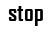

In [11]:
img = render_word("stop", font_paths[0])
img

Augmentation

In [12]:
def augment(img):
    if random.random() < 0.5:
        angle = random.uniform(-3, 3)
        img = img.rotate(angle, fillcolor=255, expand=False)
    if random.random() < 0.3:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.3, 1.0)))
    return img

Word source

In [9]:
def random_string(min_len=2, max_len=10):
    chars = string.ascii_lowercase + string.digits
    length = random.randint(min_len, max_len)
    return ''.join(random.choices(chars, k=length))

dictionary_words = ["stop", "hello", "world", "notification", "at", "the", "and",
                     "recognition", "transformer", "python", "image", "attention",
                     "network", "training", "model", "vision", "encoder", "decoder"]

def get_word(dict_ratio=0.7):
    if random.random() < dict_ratio:
        return random.choice(dictionary_words)
    return random_string()

Generate a small batch - 500 images to validate the pipeline

In [8]:
os.makedirs("../data/synth/train", exist_ok=True)

labels = []
N = 500
for i in range(N):
    word = get_word()
    font = random.choice(font_paths)
    size = random.randint(20, 28)
    img = render_word(word, font, font_size=size)
    img = augment(img)
    fname = f"{i:05d}.png"
    img.save(f"../data/synth/train/{fname}")
    labels.append((fname, word))

with open("../data/synth/train/labels.txt", "w") as f:
    for fname, word in labels:
        f.write(f"{fname}\t{word}\n")

print(f"generated {N} images")

generated 500 images


Visually verify a handful

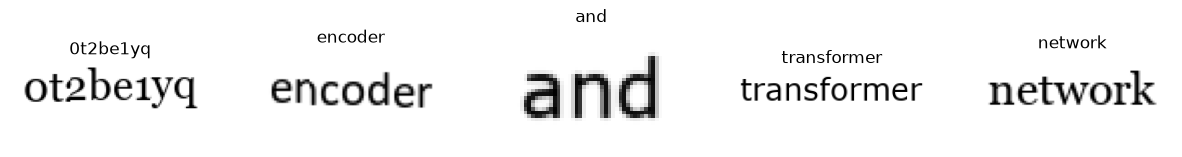

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, (fname, word) in zip(axes, labels[:5]):
    img = Image.open(f"../data/synth/train/{fname}")
    ax.imshow(img, cmap='gray')
    ax.set_title(word)
    ax.axis('off')
plt.show()

Pull a real word list

In [13]:
import urllib.request

url = "https://raw.githubusercontent.com/first20hours/google-10000-english/master/google-10000-english-no-swears.txt"
urllib.request.urlretrieve(url, "../data/wordlist.txt")

with open("../data/wordlist.txt") as f:
    dictionary_words = [w.strip() for w in f if w.strip().isalpha() and len(w.strip()) >= 2]

print(len(dictionary_words), dictionary_words[:10])

9868 ['the', 'of', 'and', 'to', 'in', 'for', 'is', 'on', 'that', 'by']


Generate at scale, with a progress indicator

In [4]:
from tqdm import tqdm   # pip install tqdm if you don't have it

os.makedirs("../data/synth/train_v2", exist_ok=True)

def get_word_v2(dict_ratio=0.7):
    if random.random() < dict_ratio:
        return random.choice(dictionary_words)
    return random_string()

labels_out = []
N = 50000
for i in tqdm(range(N)):
    word = get_word_v2()
    font = random.choice(font_paths)
    size = random.randint(20, 28)
    img = render_word(word, font, font_size=size)
    img = augment(img)
    fname = f"{i:06d}.png"
    img.save(f"../data/synth/train_v2/{fname}")
    labels_out.append((fname, word))

with open("../data/synth/train_v2/labels.txt", "w") as f:
    for fname, word in labels_out:
        f.write(f"{fname}\t{word}\n")

print(f"generated {N} images")

  0%|          | 0/50000 [00:00<?, ?it/s]


NameError: name 'dictionary_words' is not defined

Sanity check word diversity

In [16]:
from collections import Counter
word_counts = Counter(w for _, w in labels_out)
print("unique words:", len(word_counts))
print("most common:", word_counts.most_common(5))

unique words: 23512
most common: [('properly', 12), ('recall', 11), ('expedia', 11), ('tm', 11), ('separate', 11)]


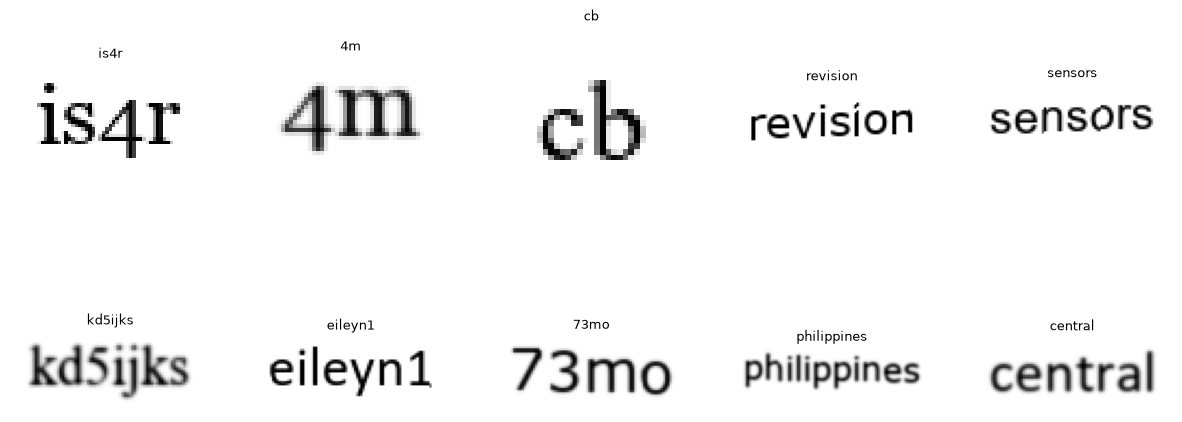

In [17]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
sample = random.sample(labels_out, 10)
for ax, (fname, word) in zip(axes.flat, sample):
    img = Image.open(f"../data/synth/train_v2/{fname}")
    ax.imshow(img, cmap='gray')
    ax.set_title(word, fontsize=9)
    ax.axis('off')
plt.show()

In [10]:
from tqdm import tqdm

os.makedirs("../data/synth/eval_fresh", exist_ok=True)
eval_labels = []
for i in tqdm(range(1000)):
    word = get_word_v2()
    font = random.choice(font_paths)
    size = random.randint(20, 28)
    img = render_word(word, font, font_size=size)
    img = augment(img)
    fname = f"eval_{i:05d}.png"
    img.save(f"../data/synth/eval_fresh/{fname}")
    eval_labels.append((fname, word))

with open("../data/synth/eval_fresh/labels.txt", "w") as f:
    for fname, word in eval_labels:
        f.write(f"{fname}\t{word}\n")

print(f"generated {len(eval_labels)} eval images")

100%|██████████| 1000/1000 [00:01<00:00, 772.07it/s]

generated 1000 eval images


Updated generation

In [3]:

import glob


FONT_DIR = "C:/Windows/Fonts"
font_paths = glob.glob(os.path.join(FONT_DIR, "*.ttf"))

def font_is_usable(font_path, test_word="hello0129"):
    try:
        font = ImageFont.truetype(font_path, 24)
        dummy = Image.new('L', (10, 10))
        draw = ImageDraw.Draw(dummy)
        bbox = draw.textbbox((0, 0), test_word, font=font)
        return (bbox[2]-bbox[0]) > 20 and (bbox[3]-bbox[1]) > 5
    except Exception:
        return False

bad_fonts = {
    "webdings.ttf", "wingding.ttf", "WINGDNG2.TTF", "WINGDNG3.TTF",
    "symbol.ttf", "BSSYM7.TTF", "MTEXTRA.TTF", "marlett.ttf",
    "REFSPCL.TTF", "seguisym.ttf", "SegoeIcons.ttf", "segmdl2.ttf",
    "l_10646.ttf", "himalaya.ttf", "mmrtext.ttf", "mmrtextb.ttf",
    "ntailu.ttf", "ntailub.ttf", "taile.ttf", "taileb.ttf",
    "msyi.ttf", "javatext.ttf", "phagspa.ttf", "phagspab.ttf",
    "simsunb.ttf", "SimsunExtG.ttf",
}

good_fonts = [f for f in font_paths if font_is_usable(f) and os.path.basename(f) not in bad_fonts]
print(len(good_fonts))

294


In [4]:
plain_keywords = ['arial','calibri','cour','times','verdana','georgia','tahoma',
                   'trebuc','segoeui','consola','candara','corbel','constan']
plain_fonts = [f for f in good_fonts if any(k in os.path.basename(f).lower() for k in plain_keywords)]
print(f"{len(plain_fonts)} plain fonts out of {len(good_fonts)} total")

def pick_font(plain_ratio=0.8):
    if random.random() < plain_ratio and plain_fonts:
        return random.choice(plain_fonts)
    return random.choice(good_fonts)

62 plain fonts out of 294 total


Word source with longer strings

In [7]:
with open("../data/wordlist.txt") as f:
    dictionary_words = [w.strip() for w in f if w.strip().isalpha() and len(w.strip()) >= 2]

def random_string(min_len=2, max_len=14):
    chars = string.ascii_lowercase + string.digits
    length = random.randint(min_len, max_len)
    return ''.join(random.choices(chars, k=length))

def get_word(dict_ratio=0.7):
    if random.random() < dict_ratio:
        return random.choice(dictionary_words)
    return random_string()

70k dataset

In [13]:
from tqdm import tqdm 
os.makedirs("../data/recognition/synth/train_v3/", exist_ok=True)
labels = []
N = 70000
for i in tqdm(range(N)):
    word = get_word()
    font = pick_font()
    size = random.randint(20, 28)
    img = render_word(word, font, font_size=size)
    img = augment(img)
    fname = f"{i:06d}.png"
    img.save(f"../data/recognition/synth/train_v3/{fname}")
    labels.append((fname, word))

with open("../data/recognition/synth/train_v3/labels.txt", "w") as f:
    for fname, word in labels:
        f.write(f"{fname}\t{word}\n")

print(f"generated {N} images")

100%|██████████| 70000/70000 [01:20<00:00, 864.46it/s] 


generated 70000 images


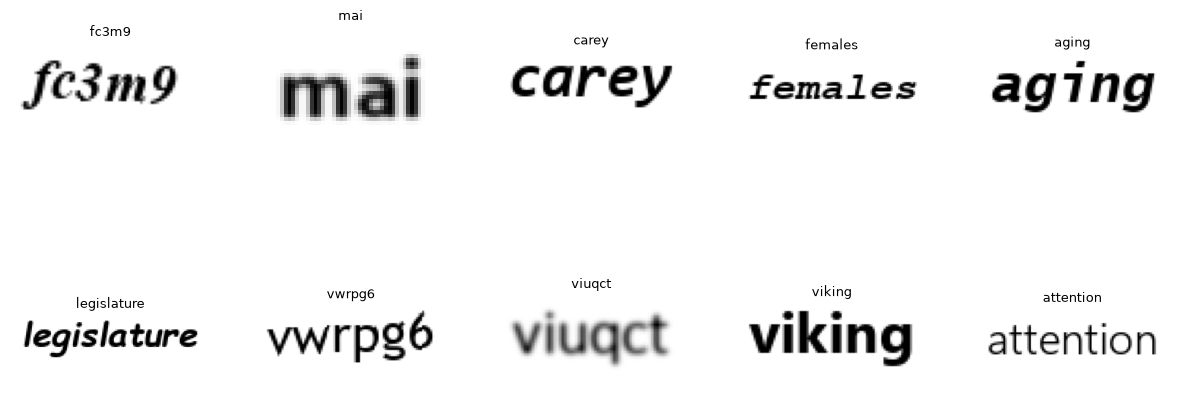

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
sample = random.sample(labels, 10)
for ax, (fname, word) in zip(axes.flat, sample):
    img = Image.open(f"../data/recognition/synth/train_v3/{fname}")
    ax.imshow(img, cmap='gray')
    ax.set_title(word, fontsize=9)
    ax.axis('off')
plt.show()

In [17]:
from collections import Counter
sample_fonts = [os.path.basename(pick_font()) for _ in range(1000)]
plain_count = sum(1 for f in sample_fonts if any(k in f.lower() for k in plain_keywords))
print(f"{plain_count}/1000 plain ({plain_count/10:.1f}%)")

850/1000 plain (85.0%)
